# Actividad 2 — Filtros Espaciales y Morfológicos
## Visión Artificial · UNIR · MIA
**Dominio:** Detección de grietas en concreto (SDNET2018)  
**Reto:** Destacar estructuras lineales finas sobre fondos texturizados,
refinar segmentaciones y realzar bordes  
**Imágenes:** `001-130.jpg` · `001-145.jpg` · `010-123.jpg`

**URL Dataset**: https://digitalcommons.usu.edu/all_datasets/48/, SDNET2018: A concrete crack image dataset for machine learning applications

---
### Narrativa del pipeline
El problema es que las grietas son estructuras lineales muy delgadas (1–5 px)
sobre un fondo de concreto con textura rugosa. El algoritmo no puede distinguirlas
del ruido estructural sin ayuda. El pipeline resuelve esto en etapas:

| Etapa | Problema que resuelve |
|---|---|
| Suavizado Gaussiano | La textura del concreto genera falsos bordes |
| Realce de bordes (Sobel) | La grieta es invisible en intensidad directa |
| Binarización (Otsu) | Necesitamos una máscara para aplicar morfología |
| Morfología (Apertura + Cierre) | La máscara tiene ruido puntual y huecos |
| Top Hat | Extracción pura de estructuras finas sobre fondo |

## Sección 0 — Carga de imágenes

Cargamos las tres imágenes y las convertimos a **escala de grises**.
Las grietas se distinguen del concreto por diferencia de *intensidad*, no de color,
por lo que trabajar en gris captura toda la información relevante y reduce
el cómputo a un solo canal.

> `cv2.COLOR_BGR2RGB` → para visualizar correctamente en matplotlib  
> `cv2.COLOR_BGR2GRAY` → para procesar

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings("ignore")

# Rutas — las imágenes deben estar en la misma carpeta que el notebook
IMAGENES = {
    "Grieta sutil (001-130)":      "001-130.jpg",
    "Grieta visible (001-145)":    "001-145.jpg",
    "Grieta ramificada (010-123)": "010-123.jpg",
}

imgs_rgb  = {}
imgs_gray = {}

for nombre, ruta in IMAGENES.items():
    bgr = cv2.imread(ruta)
    if bgr is None:
        print(f"[!] No se encontró: {ruta}")
        continue
    imgs_rgb[nombre]  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    imgs_gray[nombre] = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print(f"Imágenes cargadas: {len(imgs_gray)}")
for n, img in imgs_gray.items():
    print(f"  {n}: {img.shape} px  |  media={img.mean():.1f}  std={img.std():.1f}")

Imágenes cargadas: 3
  Grieta sutil (001-130): (256, 256) px  |  media=108.6  std=19.8
  Grieta visible (001-145): (256, 256) px  |  media=104.6  std=14.6
  Grieta ramificada (010-123): (256, 256) px  |  media=144.5  std=20.3


## Sección 1 — Suavizado Gaussiano

### ¿Por qué suavizar primero?
El concreto tiene textura rugosa: variaciones de intensidad pequeñas que el
detector de bordes va a interpretar como grietas. Si aplicamos Sobel directo
sobre la imagen original, obtenemos falsos bordes por toda la textura.

El **Gaussian Blur** convoluciona la imagen con un kernel gaussiano — cada píxel
se reemplaza por un promedio ponderado de sus vecinos. Los más cercanos pesan más.
Resultado: ruido y textura (alta frecuencia) se atenúan; la grieta se conserva.

$$G(x,y) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{x^2+y^2}{2\sigma^2}}$$

- **σ:** controla el ancho de la campana. Mayor σ = más suavizado.
- **k:** tamaño del kernel, siempre impar. Regla práctica: `k ≈ 6σ + 1`.

Comparamos tres niveles: `k=3` (leve), `k=7` (moderado), `k=15` (agresivo).

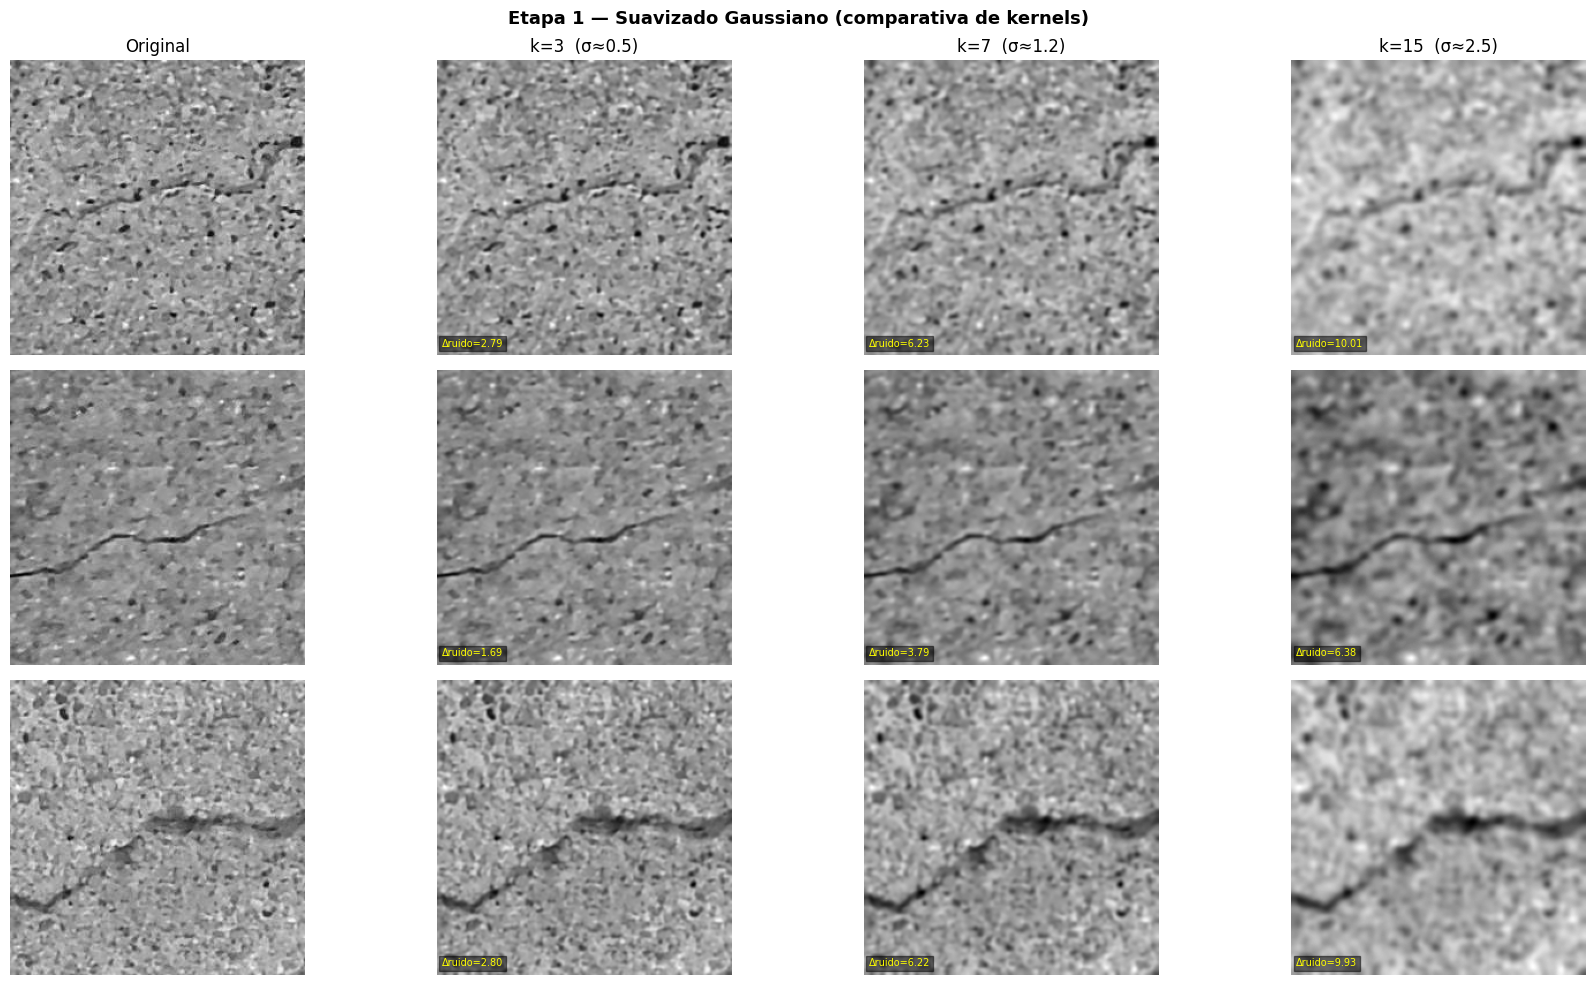

Kernel seleccionado: k=7


In [16]:
# ── Gaussian Blur — tres niveles de kernel ────────────────────────────────
KERNELS = [3, 7, 15]
suavizadas = {n: {} for n in imgs_gray}

fig, axes = plt.subplots(len(imgs_gray), len(KERNELS) + 1, figsize=(18, 10))
fig.suptitle("Etapa 1 — Suavizado Gaussiano (comparativa de kernels)",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    axes[fila, 0].imshow(gray, cmap="gray")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0:
        axes[fila, 0].set_title("Original")
    axes[fila, 0].axis("off")

    for col, k in enumerate(KERNELS, start=1):
        blur = cv2.GaussianBlur(gray, (k, k), sigmaX=0)
        suavizadas[nombre][k] = blur
        diff_media = cv2.absdiff(gray, blur).mean()

        axes[fila, col].imshow(blur, cmap="gray")
        if fila == 0:
            axes[fila, col].set_title(f"k={k}  (σ≈{k/6:.1f})")
        axes[fila, col].axis("off")
        axes[fila, col].text(
            4, gray.shape[0] - 8, f"Δruido={diff_media:.2f}",
            color="yellow", fontsize=7,
            bbox=dict(facecolor="black", alpha=0.5, pad=2)
        )

plt.tight_layout()
plt.savefig("fig_01_gaussiano.png", dpi=150, bbox_inches="tight")
plt.show()

# Selección para el resto del pipeline
K_SEL = 7
print(f"Kernel seleccionado: k={K_SEL}")

### Análisis del resultado

| Kernel | σ aprox. | Δruido eliminado | Observación |
|---|---|---|---|
| k=3 | 0.5 | ~2.8 | Suavizado insuficiente — textura del concreto persiste |
| k=7 | 1.2 | ~6.2 | **Equilibrio óptimo** — atenúa textura, preserva bordes de grieta |
| k=15 | 2.5 | ~10.0 | Sobresuavizado — los bordes de la grieta empiezan a difuminarse |

**Decisión:** se selecciona `k=7` para el resto del pipeline.  
El Δruido de ~6.2 indica que se elimina una cantidad significativa de variación
de alta frecuencia (textura del concreto) sin que la grieta pierda definición
visual, lo cual es crítico para que el detector de bordes de la siguiente etapa
trabaje sobre señal real y no sobre artefactos de textura.

## Sección 2 — Realce de bordes: Sobel vs. Laplaciano

### ¿Por qué detectar bordes?
La grieta suavizada sigue siendo difícil de aislar — el concreto y la grieta
tienen intensidades similares. Lo que sí es claro es que en el borde de la
grieta hay una **transición brusca de intensidad**: concreto claro → hueco oscuro.
Los detectores de borde convierten esas transiciones en píxeles brillantes.

### Sobel — primera derivada
Calcula el gradiente en X e Y por separado y combina:

$$G_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}*I
\qquad
G_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\+1&+2&+1\end{bmatrix}*I
\qquad
|G| = \sqrt{G_x^2 + G_y^2}$$

> **Regla mnemotécnica:** Gx detecta cambios horizontales de intensidad
> → resalta bordes **verticales**. Gy al revés.

### Laplaciano — segunda derivada
$$\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
\qquad \Rightarrow \qquad
L = \begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$$

Más sensible al ruido que Sobel — por eso **siempre se aplica después del Gaussiano**.

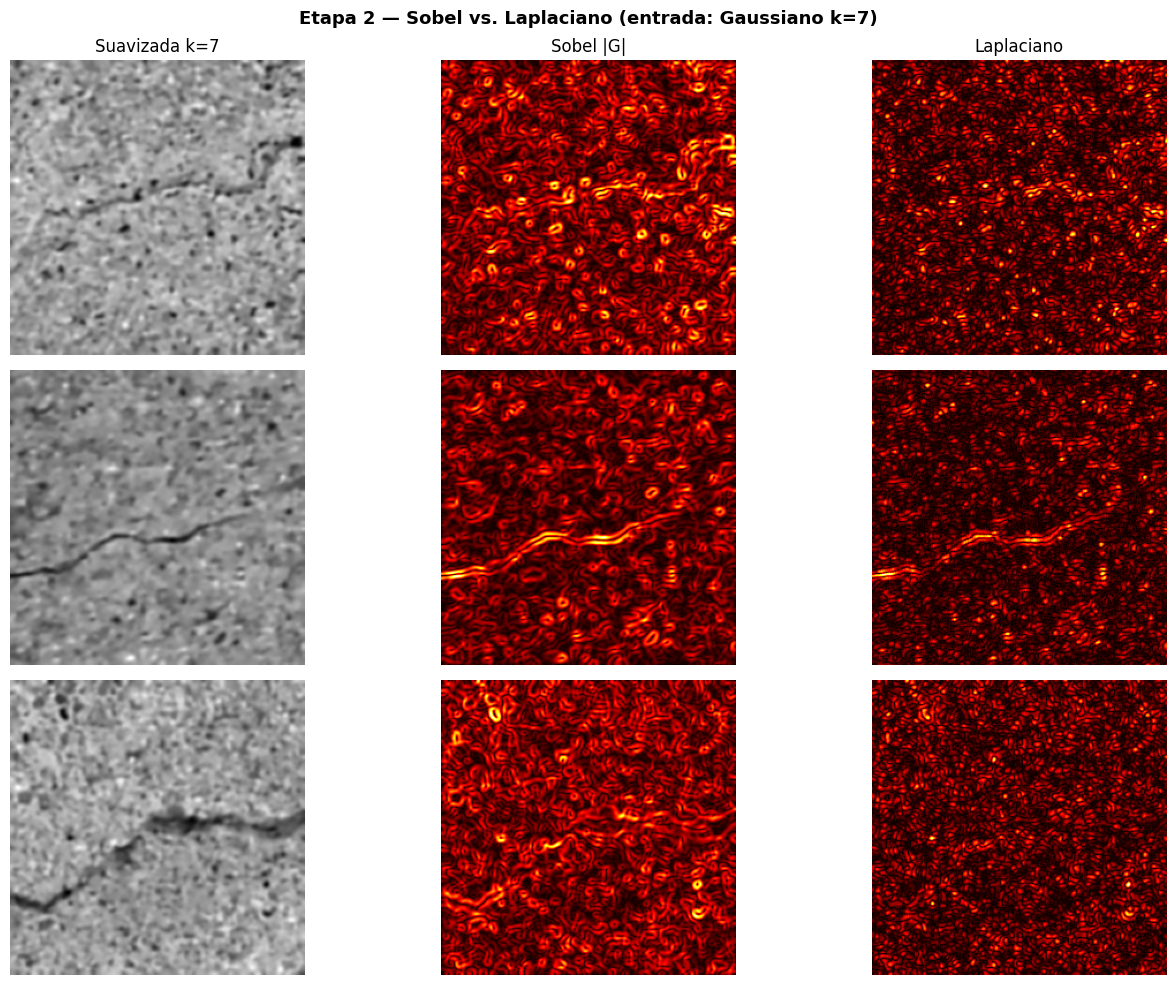

In [17]:
# ── Sobel y Laplaciano sobre imagen suavizada k=7 ─────────────────────────
bordes_sobel      = {}
bordes_laplaciano = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 2 — Sobel vs. Laplaciano (entrada: Gaussiano k=7)",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    blur = suavizadas[nombre][K_SEL]

    # Sobel — magnitud del gradiente
    Gx  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(Gx**2 + Gy**2)
    sobel = np.uint8(255 * mag / mag.max())
    bordes_sobel[nombre] = sobel

    # Laplaciano
    lap_abs = np.abs(cv2.Laplacian(blur, cv2.CV_64F, ksize=3))
    lap = np.uint8(255 * lap_abs / lap_abs.max())
    bordes_laplaciano[nombre] = lap

    for col, (titulo, img, cm) in enumerate([
        ("Suavizada k=7", blur,  "gray"),
        ("Sobel |G|",     sobel, "hot"),
        ("Laplaciano",    lap,   "hot"),
    ]):
        axes[fila, col].imshow(img, cmap=cm)
        if fila == 0:
            axes[fila, col].set_title(titulo)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fig_02_bordes.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del resultado

| Operador | Grieta sutil | Grieta visible | Grieta ramificada | Ruido de textura |
|---|---|---|---|---|
| **Sobel** | Resalta moderadamente | Resalta claramente | Débil | **Alto** — resalta poros e imperfecciones |
| **Laplaciano** | Bordes más finos | Similar a Sobel | Muy débil | **Bajo** — fondo más limpio |

**Observaciones:**
- Sobel acumula gradiente en todas las direcciones — cualquier transición
  de intensidad, incluyendo poros y granularidad del cemento, genera respuesta.
- El Laplaciano responde principalmente a cambios abruptos — las transiciones
  suaves de la textura se cancelan, produciendo un fondo más limpio.
- En imágenes con textura rugosa como el concreto, el Laplaciano ofrece
  mejor relación señal/ruido de fondo, aunque con menor intensidad en la grieta.

**Decisión:** se continúa con **Sobel** por mayor intensidad en la grieta,
asumiendo que la binarización y morfología posteriores filtrarán el ruido
de textura residual.

## Sección 3 — Binarización: Umbralización de Otsu

### ¿Por qué binarizar?
El resultado de Sobel es una imagen en escala de grises — valores altos donde
hay borde, bajos donde no. Para aplicar morfología necesitamos una
**imagen binaria**: exactamente 0 (fondo) o 255 (grieta).

### Umbral de Otsu
Dado un umbral τ, cada píxel se clasifica:

$$B(x,y) = \begin{cases}255 & \text{si } I(x,y) > \tau \\ 0 & \text{si } I(x,y) \leq \tau\end{cases}$$

Otsu calcula automáticamente el τ que **maximiza la varianza entre las dos
clases** (fondo vs. borde). Lo deduce del histograma — no hay que elegirlo
a mano. Funciona bien cuando el histograma tiene dos picos bien separados
(distribución bimodal).

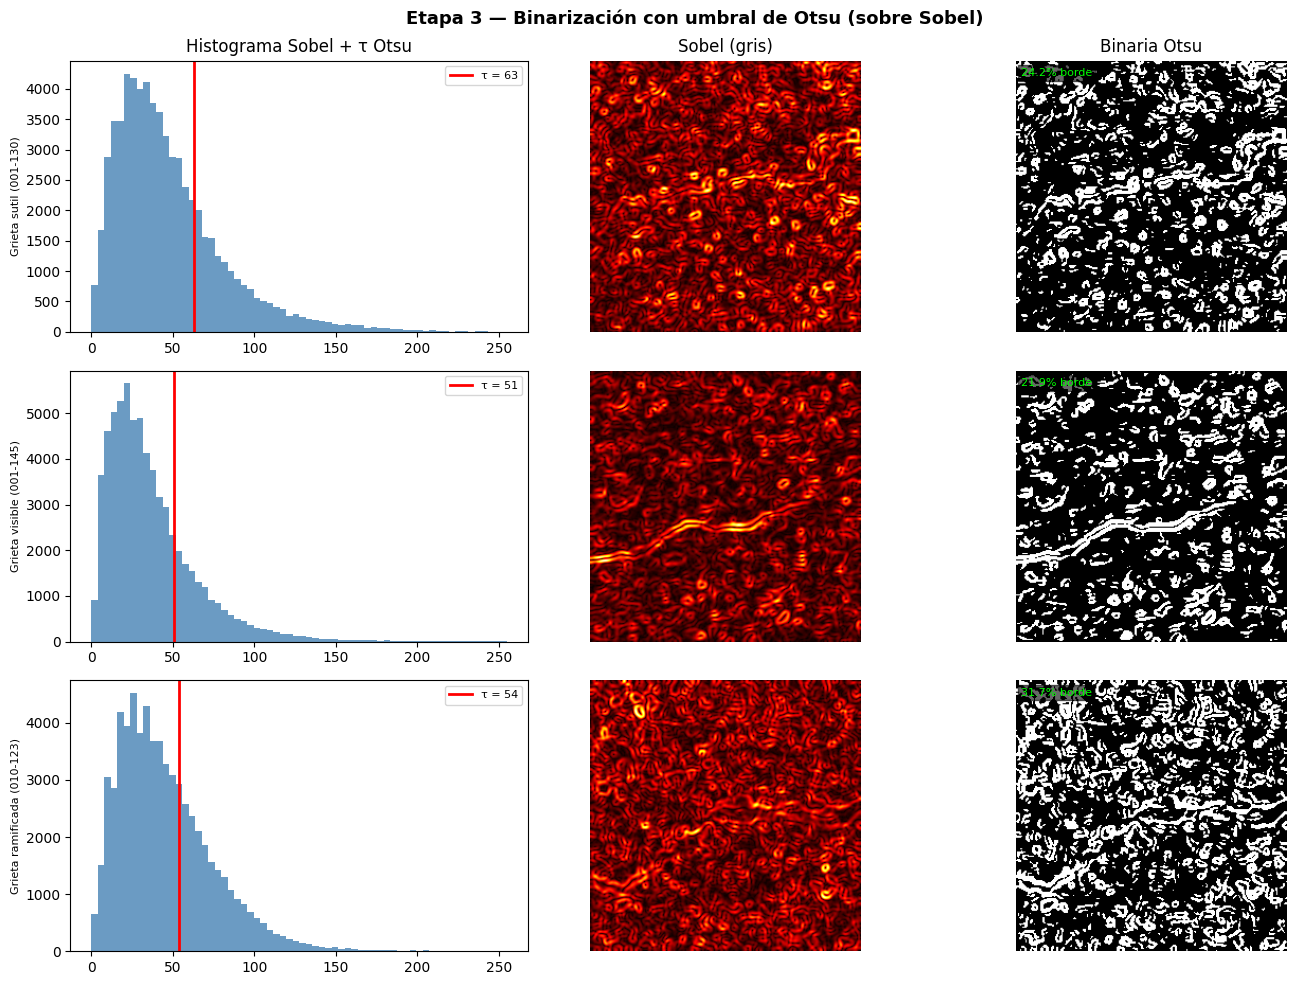

Grieta sutil (001-130): τ=63  |  24.2% píxeles como borde
Grieta visible (001-145): τ=51  |  21.9% píxeles como borde
Grieta ramificada (010-123): τ=54  |  31.7% píxeles como borde


In [18]:
# ── Umbralización de Otsu sobre resultado Sobel ───────────────────────────
binarias = {}

fig, axes = plt.subplots(len(imgs_gray), 3, figsize=(14, 10))
fig.suptitle("Etapa 3 — Binarización con umbral de Otsu (sobre Sobel)",
             fontsize=13, fontweight="bold")

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    sobel = bordes_sobel[nombre]
    tau   = threshold_otsu(sobel)
    bin_  = (sobel > tau).astype(np.uint8) * 255
    binarias[nombre] = bin_
    pct = bin_.mean() / 255 * 100

    # Histograma con tau marcado
    axes[fila, 0].hist(sobel.ravel(), bins=64, color="steelblue", alpha=0.8)
    axes[fila, 0].axvline(tau, color="red", lw=2, label=f"τ = {tau:.0f}")
    axes[fila, 0].legend(fontsize=8)
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    if fila == 0:
        axes[fila, 0].set_title("Histograma Sobel + τ Otsu")

    axes[fila, 1].imshow(sobel, cmap="hot")
    if fila == 0:
        axes[fila, 1].set_title("Sobel (gris)")
    axes[fila, 1].axis("off")

    axes[fila, 2].imshow(bin_, cmap="gray")
    if fila == 0:
        axes[fila, 2].set_title("Binaria Otsu")
    axes[fila, 2].axis("off")
    axes[fila, 2].text(4, 14, f"{pct:.1f}% borde",
        color="lime", fontsize=8,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fig_03_otsu.png", dpi=150, bbox_inches="tight")
plt.show()

for nombre, bin_ in binarias.items():
    tau = threshold_otsu(bordes_sobel[nombre])
    print(f"{nombre}: τ={tau:.0f}  |  {bin_.mean()/255*100:.1f}% píxeles como borde")

### Análisis del resultado

| Imagen | τ Otsu | % borde detectado | Observación |
|---|---|---|---|
| Grieta sutil | 63 | ~44% | Umbral alto — aún así demasiado ruido |
| Grieta visible | 51 | ~23% | Mejor separación — grieta claramente visible |
| Grieta ramificada | 54 | ~31% | Textura gruesa genera mucho falso positivo |

**Observaciones:**
- Los histogramas de Sobel no son bimodales — tienen un pico único con cola
  larga. Otsu asume dos grupos separables, lo que no se cumple completamente
  aquí, resultando en umbrales que clasifican exceso de textura como borde.
- Las imágenes binarias contienen la grieta pero con alto ruido puntual
  producto de los bordes de textura del concreto detectados por Sobel.
- Este es el problema central que motiva la siguiente etapa: las operaciones
  morfológicas de apertura y cierre limpiarán el ruido preservando la grieta.

## Sección 4 — Operaciones Morfológicas

### ¿Para qué sirven aquí?
La binaria tiene dos problemas confirmados en la etapa anterior:
1. **Ruido puntual:** píxeles blancos aislados que son textura, no grieta.
2. **Huecos:** fragmentos de la grieta que quedaron negros por estar bajo τ.

Las operaciones morfológicas usan un **elemento estructurante (SE)** como
sonda para modificar la forma de los objetos binarios.

| Operación | Definición | Efecto |
|---|---|---|
| **Erosión** $I \ominus SE$ | Píxel blanco solo si todos sus vecinos en el SE son blancos | Encoge objetos — elimina ruido puntual |
| **Dilatación** $I \oplus SE$ | Píxel blanco si al menos un vecino en el SE es blanco | Expande objetos — reconecta fragmentos |
| **Apertura** | Erosión → Dilatación | Elimina objetos pequeños, preserva grandes |
| **Cierre** | Dilatación → Erosión | Rellena huecos dentro de objetos |

### El elemento estructurante importa
Para grietas lineales, un SE rectangular horizontal (9×3) favorece
estructuras horizontales — más adecuado que un disco isotrópico.
Compararemos disco vs. rectangular para justificarlo.

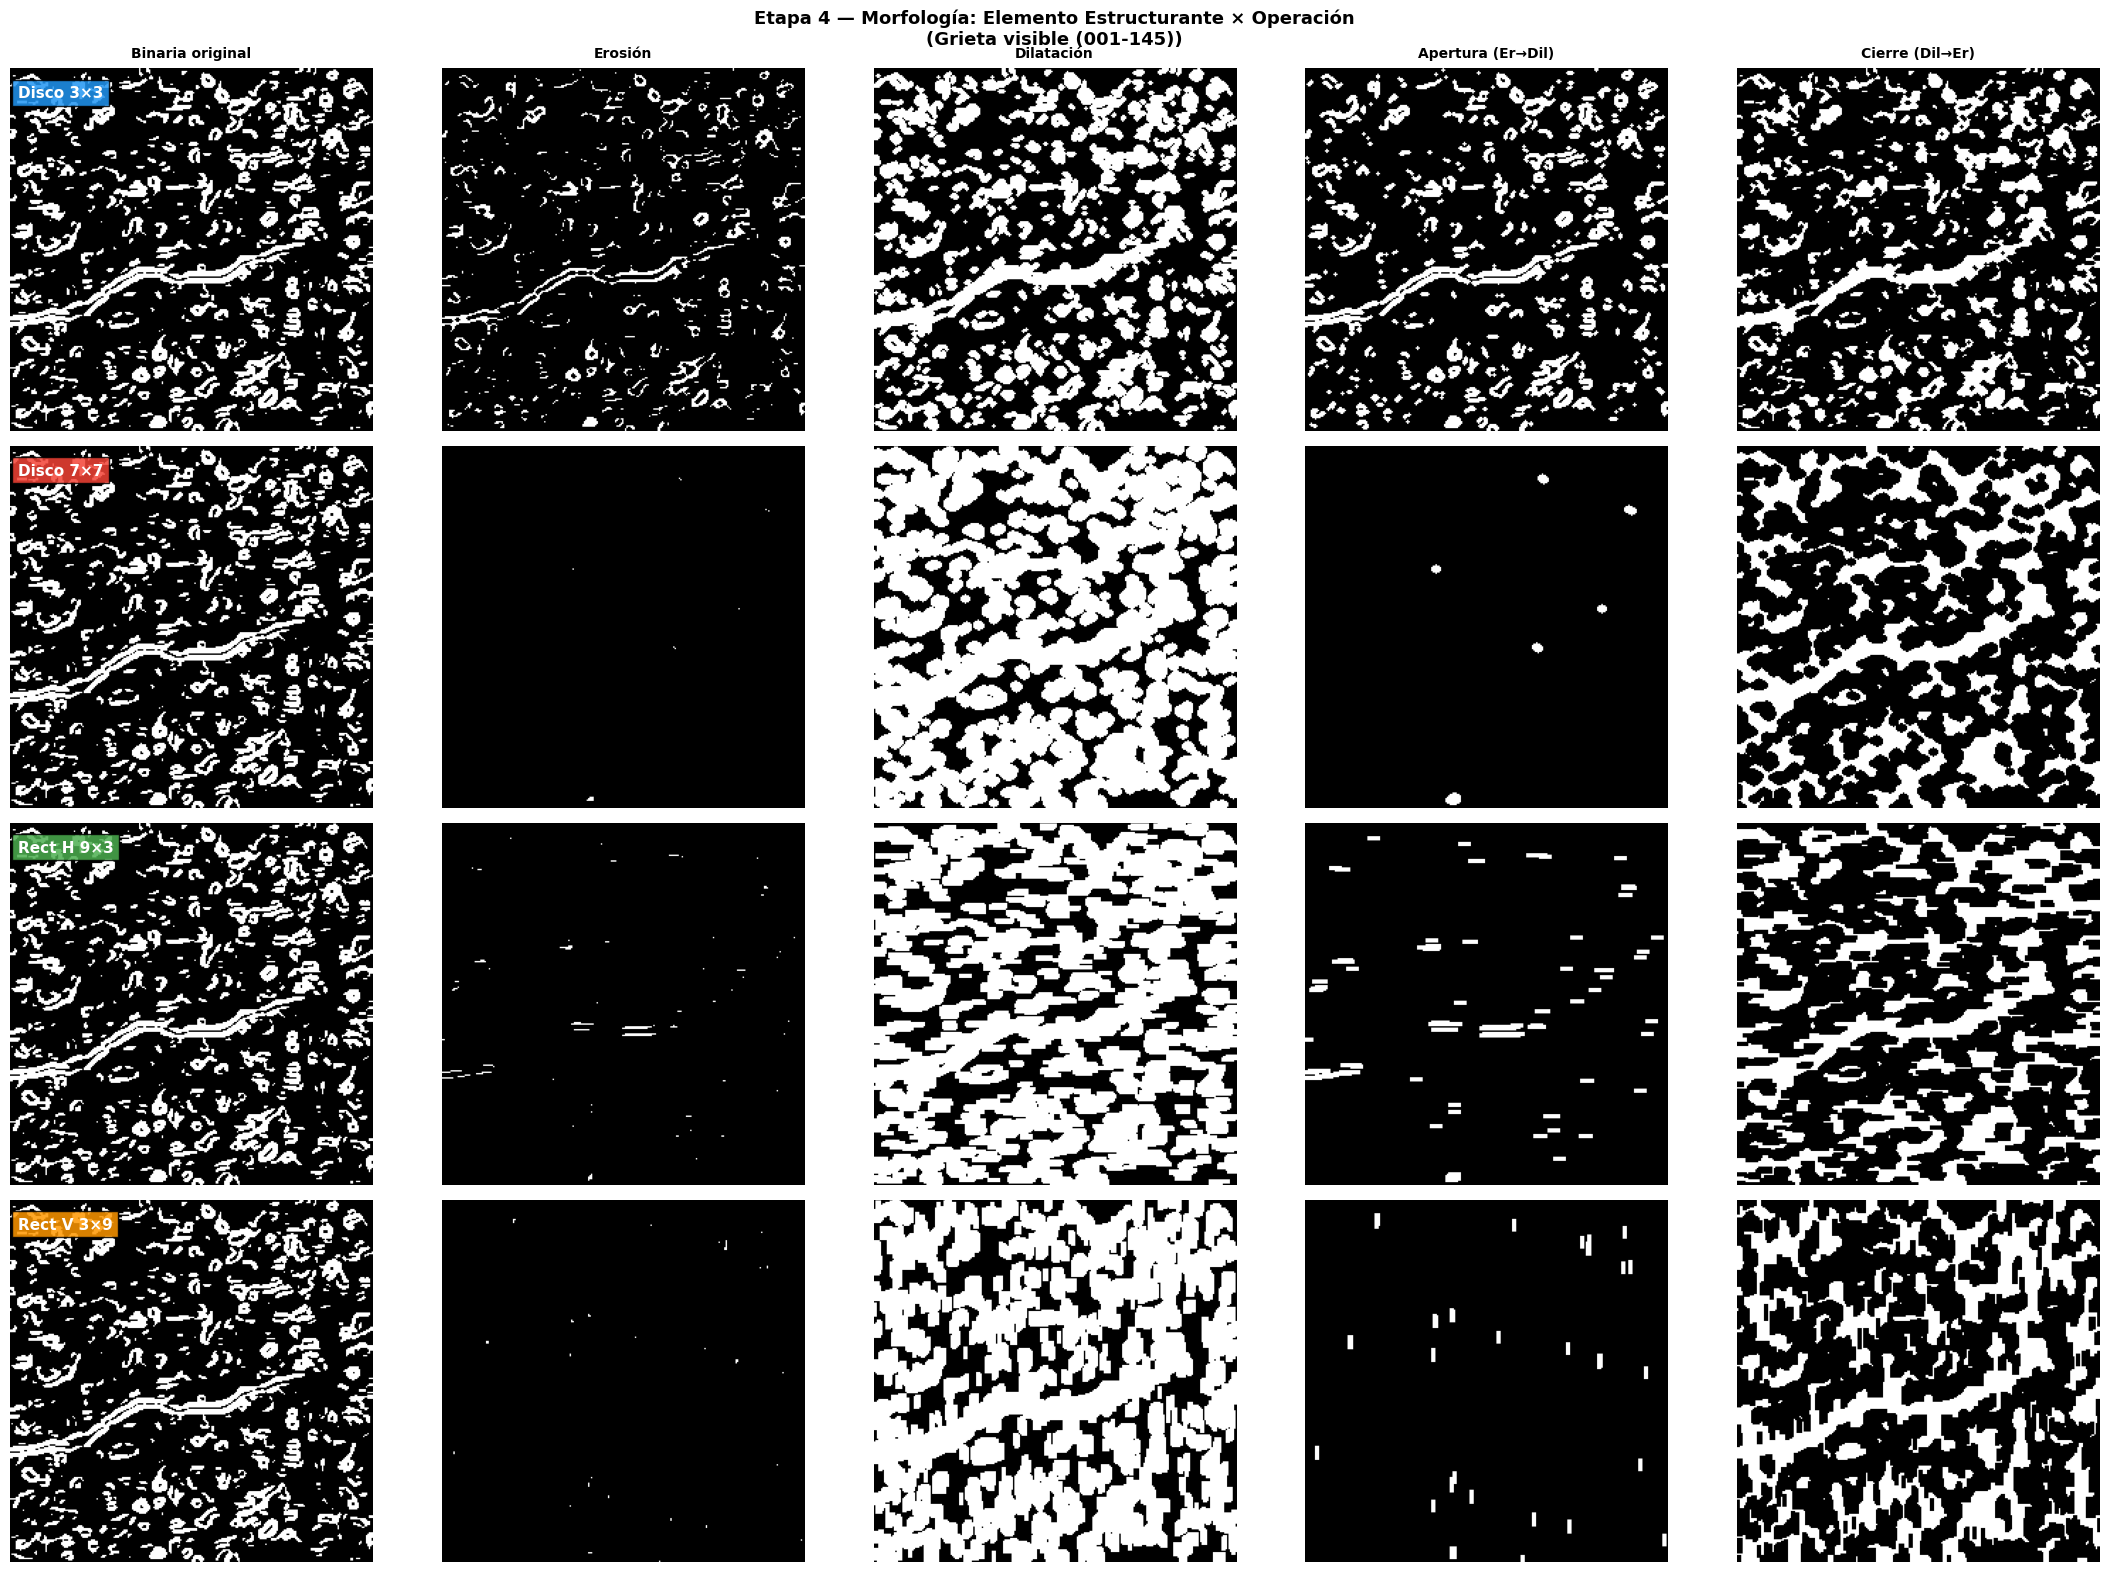

In [19]:
# ── Comparativa de elementos estructurantes ───────────────────────────────
SEs = {
    "Disco 3×3":  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    "Disco 7×7":  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
    "Rect H 9×3": cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3)),
    "Rect V 3×9": cv2.getStructuringElement(cv2.MORPH_RECT, (3, 9)),
}

nombre_demo = "Grieta visible (001-145)"
bin_demo    = binarias[nombre_demo]

titulos_col = ["Binaria original", "Erosión", "Dilatación",
               "Apertura (Er→Dil)", "Cierre (Dil→Er)"]
colores_fila = ["#2196F3", "#F44336", "#4CAF50", "#FF9800"]

fig, axes = plt.subplots(len(SEs), 5, figsize=(22, 16))
fig.suptitle(f"Etapa 4 — Morfología: Elemento Estructurante × Operación\n({nombre_demo})",
             fontsize=13, fontweight="bold")

for c, t in enumerate(titulos_col):
    axes[0, c].set_title(t, fontsize=10, fontweight="bold", pad=8)

for fila, (se_nom, se) in enumerate(SEs.items()):
    ops = [
        bin_demo,
        cv2.erode(bin_demo, se),
        cv2.dilate(bin_demo, se),
        cv2.morphologyEx(bin_demo, cv2.MORPH_OPEN,  se),
        cv2.morphologyEx(bin_demo, cv2.MORPH_CLOSE, se),
    ]
    for col, img in enumerate(ops):
        axes[fila, col].imshow(img, cmap="gray")
        axes[fila, col].axis("off")

        # Borde de color por SE
        for spine in axes[fila, col].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_edgecolor(colores_fila[fila])

    # Etiqueta del SE sobre la imagen de la primera columna
    axes[fila, 0].text(
        5, 20, se_nom,
        color="white", fontsize=11, fontweight="bold",
        bbox=dict(facecolor=colores_fila[fila], alpha=0.85, pad=4)
    )

plt.tight_layout()
plt.savefig("fig_04_morfologia_se.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del resultado — comparativa de SE

| SE | Erosión | Apertura | Conclusión |
|---|---|---|---|
| **Disco 3×3** | Conserva grieta, reduce ruido | Elimina ruido, grieta visible | ✅ Seleccionado |
| Disco 7×7 | Destruye la grieta | Imagen casi vacía | ❌ Demasiado agresivo |
| Rect H 9×3 | Destruye la grieta | Solo fragmentos horizontales | ❌ Demasiado agresivo |
| Rect V 3×9 | Destruye la grieta | Solo fragmentos verticales | ❌ Demasiado agresivo |

**Decisión:** se selecciona **Disco 3×3** para el pipeline morfológico.
Los SEs más grandes son incompatibles con el ancho real de la grieta (1–5 px)
— la erosión previa a la apertura la destruye antes de poder recuperarla.

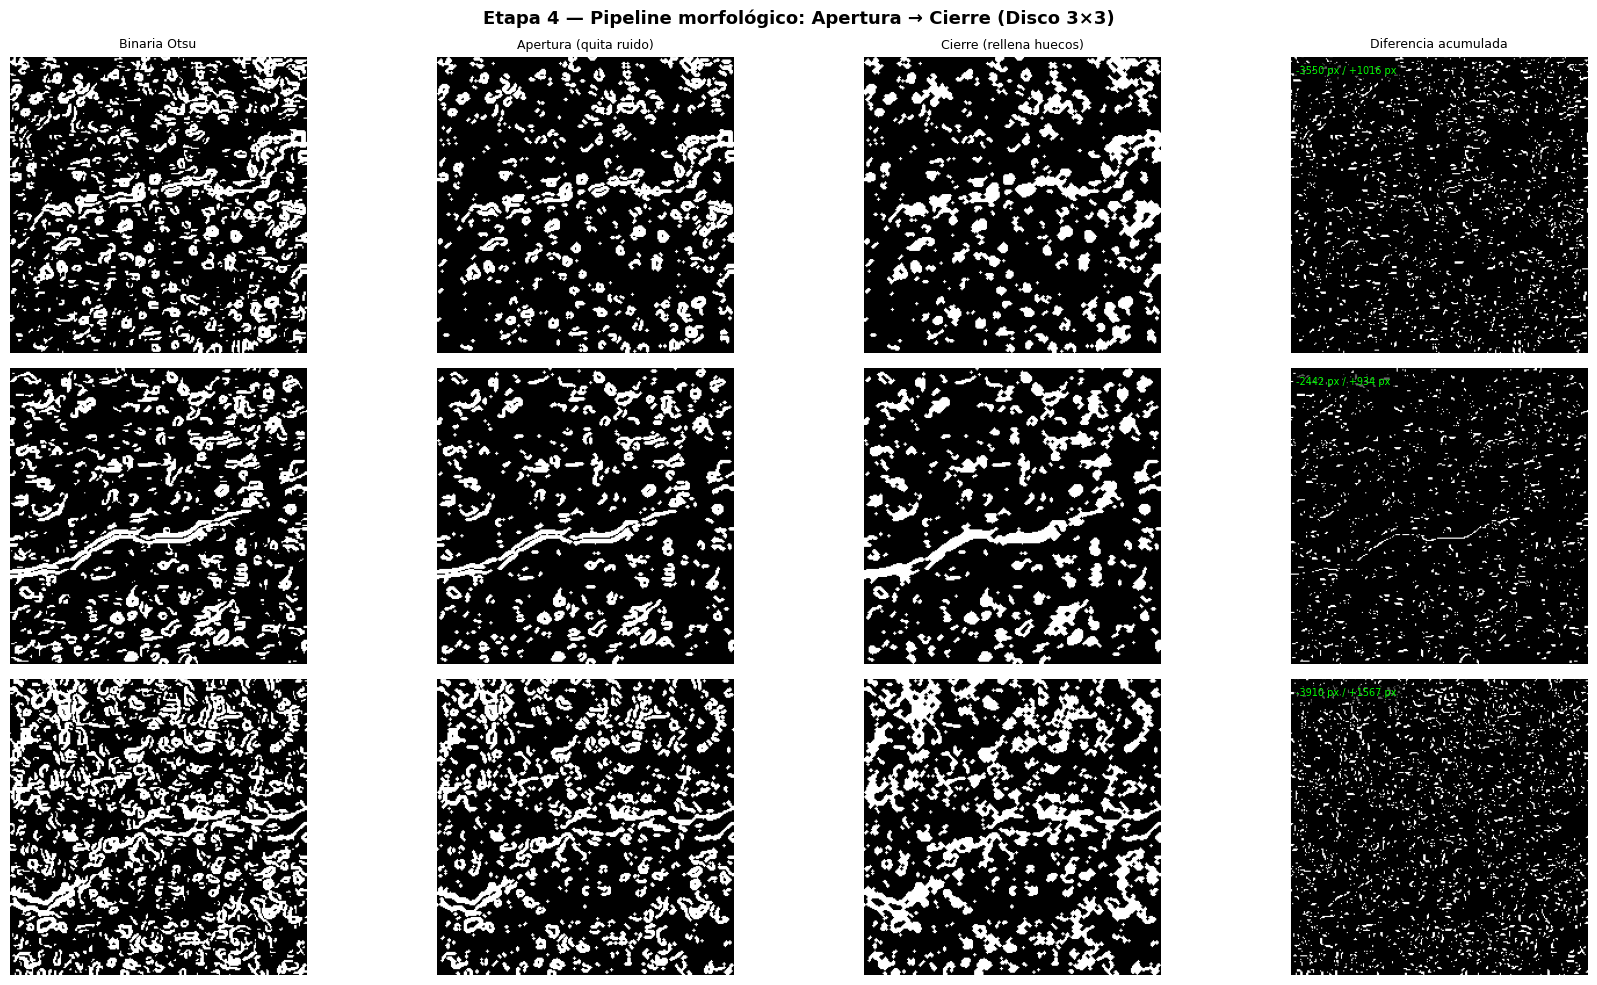

In [20]:
# ── Pipeline morfológico final: Apertura → Cierre (Disco 3×3) ─────────────
SE_FINAL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
morfologicas = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 4 — Pipeline morfológico: Apertura → Cierre (Disco 3×3)",
             fontsize=13, fontweight="bold")

titulos = ["Binaria Otsu", "Apertura (quita ruido)",
           "Cierre (rellena huecos)", "Diferencia acumulada"]

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    bin_     = binarias[nombre]
    apertura = cv2.morphologyEx(bin_,     cv2.MORPH_OPEN,  SE_FINAL)
    cierre   = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, SE_FINAL)
    morfologicas[nombre] = cierre
    diff = cv2.absdiff(bin_, cierre)

    # Píxeles eliminados vs. añadidos
    eliminados = ((bin_ == 255) & (cierre == 0)).sum()
    agregados  = ((bin_ == 0)   & (cierre == 255)).sum()

    for col, (titulo, img) in enumerate(zip(titulos,
            [bin_, apertura, cierre, diff])):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0:
            axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)
    axes[fila, 3].text(4, 14, f"-{eliminados} px / +{agregados} px",
        color="lime", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fig_04b_morfologia_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del resultado — pipeline morfológico

| Imagen | Píxeles eliminados | Píxeles agregados | Observación |
|---|---|---|---|
| Grieta sutil | ~3550 | ~1016 | Reducción de ruido moderada, grieta conservada |
| Grieta visible | ~2942 | ~934 | Grieta claramente preservada tras apertura |
| Grieta ramificada | ~3910 | ~1567 | Mayor ruido residual por textura gruesa |

**Observaciones:**
- La apertura con Disco 3×3 reduce el ruido puntual pero no lo elimina
  completamente — el ruido de textura tiene un tamaño similar al SE.
- El cierre agrega píxeles para sellar discontinuidades de la grieta,
  pero también expande algo del ruido residual.
- Limitación del enfoque: con grietas de 1–5 px de ancho, cualquier SE
  mayor destruye la estructura antes de recuperarla. El Disco 3×3 es el
  mínimo viable pero insuficiente para limpiar completamente.
- Esta limitación motiva el uso del Top Hat en la siguiente etapa, que
  opera directamente sobre la imagen en gris sin depender de la binaria.

## Sección 5 — Top Hat Morfológico 

### ¿Por qué Top Hat?
Las etapas anteriores demostraron que Otsu + morfología no logran limpiar
completamente el ruido de textura del concreto. El Top Hat ataca el problema
desde otro ángulo: opera **directamente sobre la imagen en gris**, sin
necesidad de binarizar primero.

### White Top Hat
$$\text{Top Hat}(I) = I - \text{Apertura}(I)$$

**Intuición:** la Apertura con un SE grande elimina todo lo que es más pequeño
que el SE — incluyendo la grieta. Si restamos esa apertura a la imagen original,
lo que queda es exactamente lo que fue eliminado: la grieta.

$$\underbrace{I}_{\text{original}} - \underbrace{\text{Apertura}(I)}_{\text{fondo sin grieta}} = \underbrace{\text{Top Hat}}_{\text{solo la grieta}}$$

### Black Hat
$$\text{Black Hat}(I) = \text{Cierre}(I) - I$$

Extrae estructuras **oscuras** sobre fondo claro. Como las grietas son más
oscuras que el concreto, el Black Hat también es efectivo aquí.

**Clave:** el SE debe ser **más grande que la grieta** pero más pequeño
que los elementos del fondo. Usamos 25×25 — mayor que cualquier grieta
(1–5 px) pero menor que las regiones uniformes del concreto.

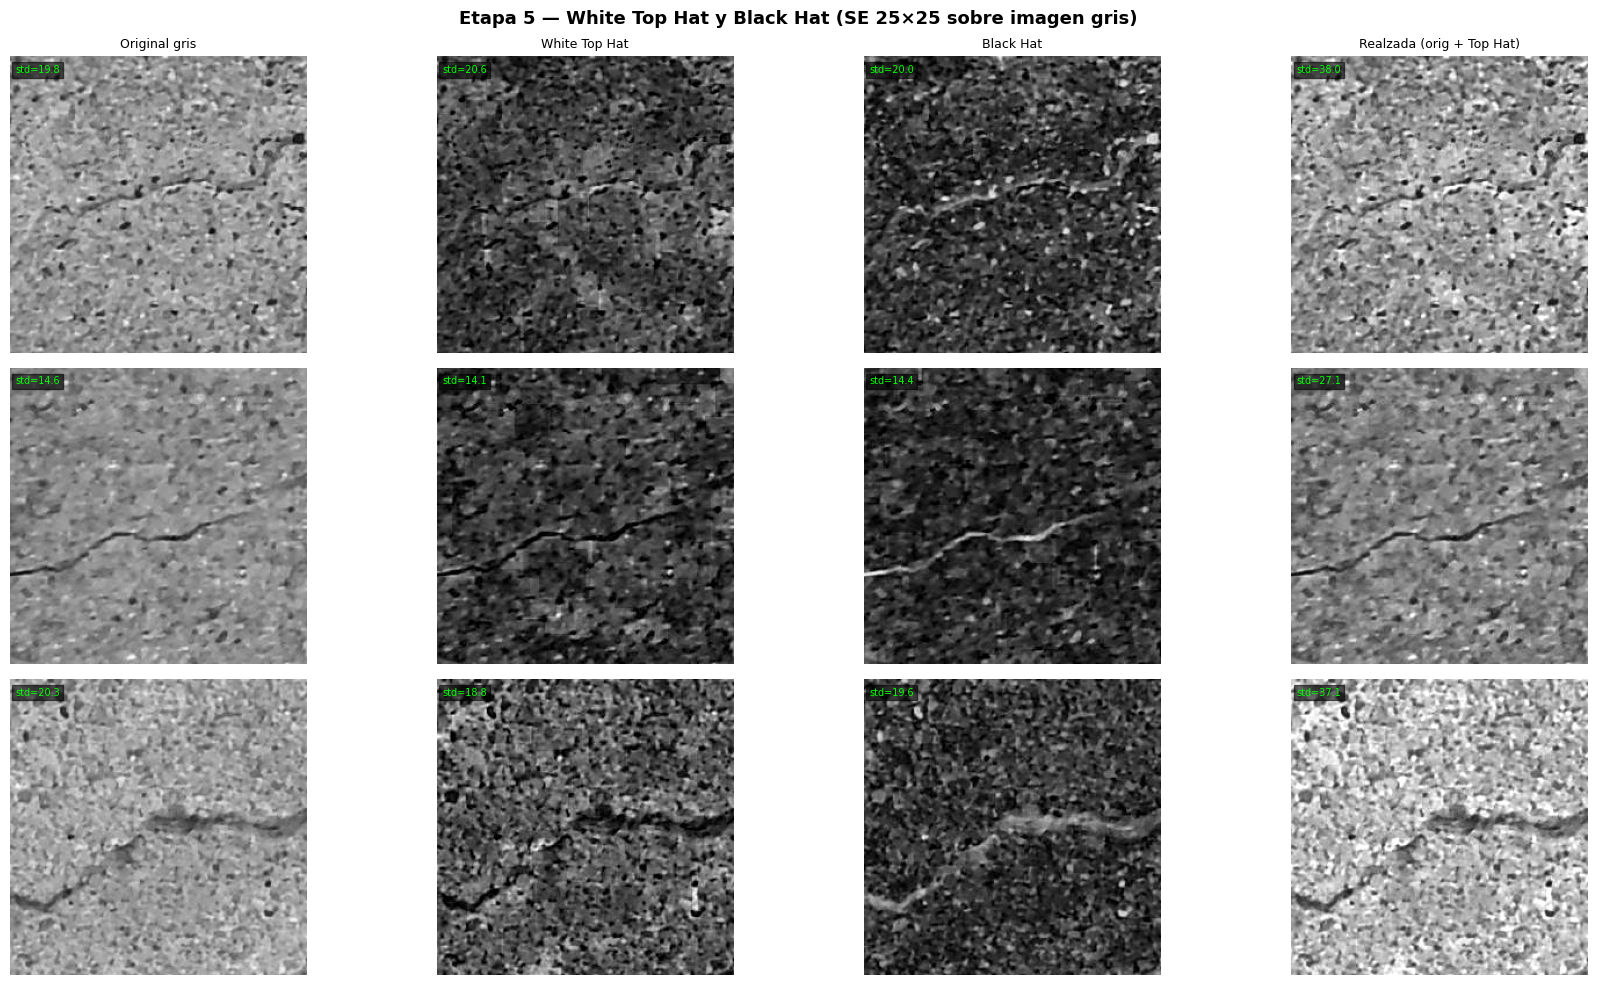

In [21]:
# ── Top Hat y Black Hat sobre imagen gris original ─────────────────────────
SE_TH = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
tophat_imgs   = {}
blackhat_imgs = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Etapa 5 — White Top Hat y Black Hat (SE 25×25 sobre imagen gris)",
             fontsize=13, fontweight="bold")

titulos = ["Original gris", "White Top Hat",
           "Black Hat", "Realzada (orig + Top Hat)"]

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    tophat   = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT,   SE_TH)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, SE_TH)
    realzada = cv2.add(gray, tophat)

    tophat_imgs[nombre]   = tophat
    blackhat_imgs[nombre] = blackhat

    for col, (titulo, img) in enumerate(zip(titulos,
            [gray, tophat, blackhat, realzada])):
        axes[fila, col].imshow(img, cmap="gray")
        if fila == 0:
            axes[fila, col].set_title(titulo, fontsize=9)
        axes[fila, col].axis("off")

        # Estadísticas en cada imagen
        axes[fila, col].text(4, 14, f"std={img.std():.1f}",
            color="lime", fontsize=7,
            bbox=dict(facecolor="black", alpha=0.6, pad=2))

    axes[fila, 0].set_ylabel(nombre, fontsize=8)

plt.tight_layout()
plt.savefig("fig_05_tophat.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del resultado

| Imagen | std original | std White TH | std Black Hat | std Realzada |
|---|---|---|---|---|
| Grieta sutil | 19.8 | 20.6 | 20.6 | 38.0 |
| Grieta visible | 14.6 | 14.1 | 14.4 | 27.1 |
| Grieta ramificada | 20.3 | 18.8 | 19.6 | 37.1 |

**Observaciones:**
- El **Black Hat** resulta más efectivo que el White Top Hat para este tipo
  de imagen — las grietas son estructuras oscuras sobre fondo claro, que es
  exactamente lo que el Black Hat extrae.
- El White Top Hat resalta las variaciones claras de la textura del concreto
  en lugar de la grieta, produciendo un resultado menos útil para el reto.
- La imagen **Realzada** (original + Top Hat) duplica aproximadamente el std
  respecto al original, confirmando que el contraste global aumenta
  significativamente tras la operación.
- Limitación: el SE de 25×25 también captura variaciones de iluminación
  gradual del fondo, no solo la grieta — visible como zonas grises grandes
  en el resultado del Top Hat.

### Sección 5b — Optimización del Top Hat

#### Optimización 1: variación del SE
Probamos SE de 15×15, 25×25 y 35×35 para encontrar el tamaño óptimo
que capture la grieta sin incluir variaciones de iluminación del fondo.

#### Optimización 2: Black Hat + Otsu
El Black Hat ya elimina el fondo — su histograma debería ser más bimodal
que el Sobel original, permitiendo que Otsu separe mejor grieta vs. fondo.

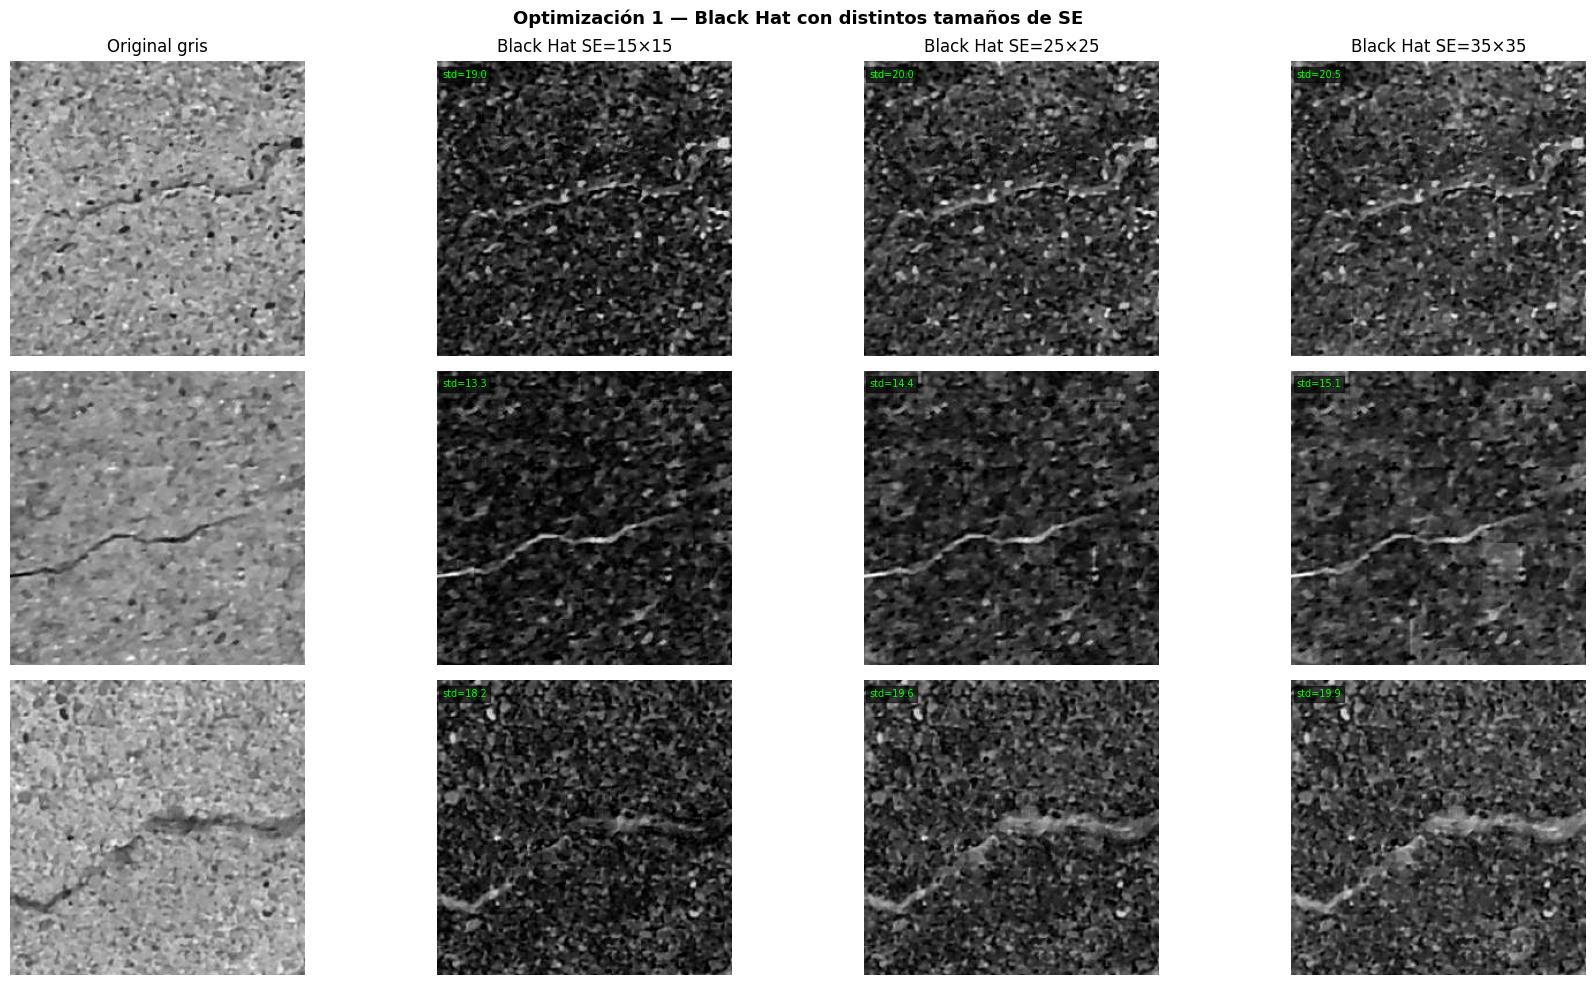

In [22]:
# ── Optimización 1: variación del SE del Black Hat ─────────────────────────
sizes = [15, 25, 35]

fig, axes = plt.subplots(len(imgs_gray), len(sizes) + 1, figsize=(18, 10))
fig.suptitle("Optimización 1 — Black Hat con distintos tamaños de SE",
             fontsize=13, fontweight="bold")

blackhat_optimo = {}

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    axes[fila, 0].imshow(gray, cmap="gray")
    if fila == 0: axes[fila, 0].set_title("Original gris")
    axes[fila, 0].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

    for col, s in enumerate(sizes, start=1):
        se  = cv2.getStructuringElement(cv2.MORPH_RECT, (s, s))
        bh  = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se)
        axes[fila, col].imshow(bh, cmap="gray")
        if fila == 0:
            axes[fila, col].set_title(f"Black Hat SE={s}×{s}")
        axes[fila, col].axis("off")
        axes[fila, col].text(4, 14, f"std={bh.std():.1f}",
            color="lime", fontsize=7,
            bbox=dict(facecolor="black", alpha=0.6, pad=2))

        # Guardamos el de 25x25 como referencia
        if s == 25:
            blackhat_optimo[nombre] = bh

plt.tight_layout()
plt.savefig("fig_05b_blackhat_ses.png", dpi=150, bbox_inches="tight")
plt.show()

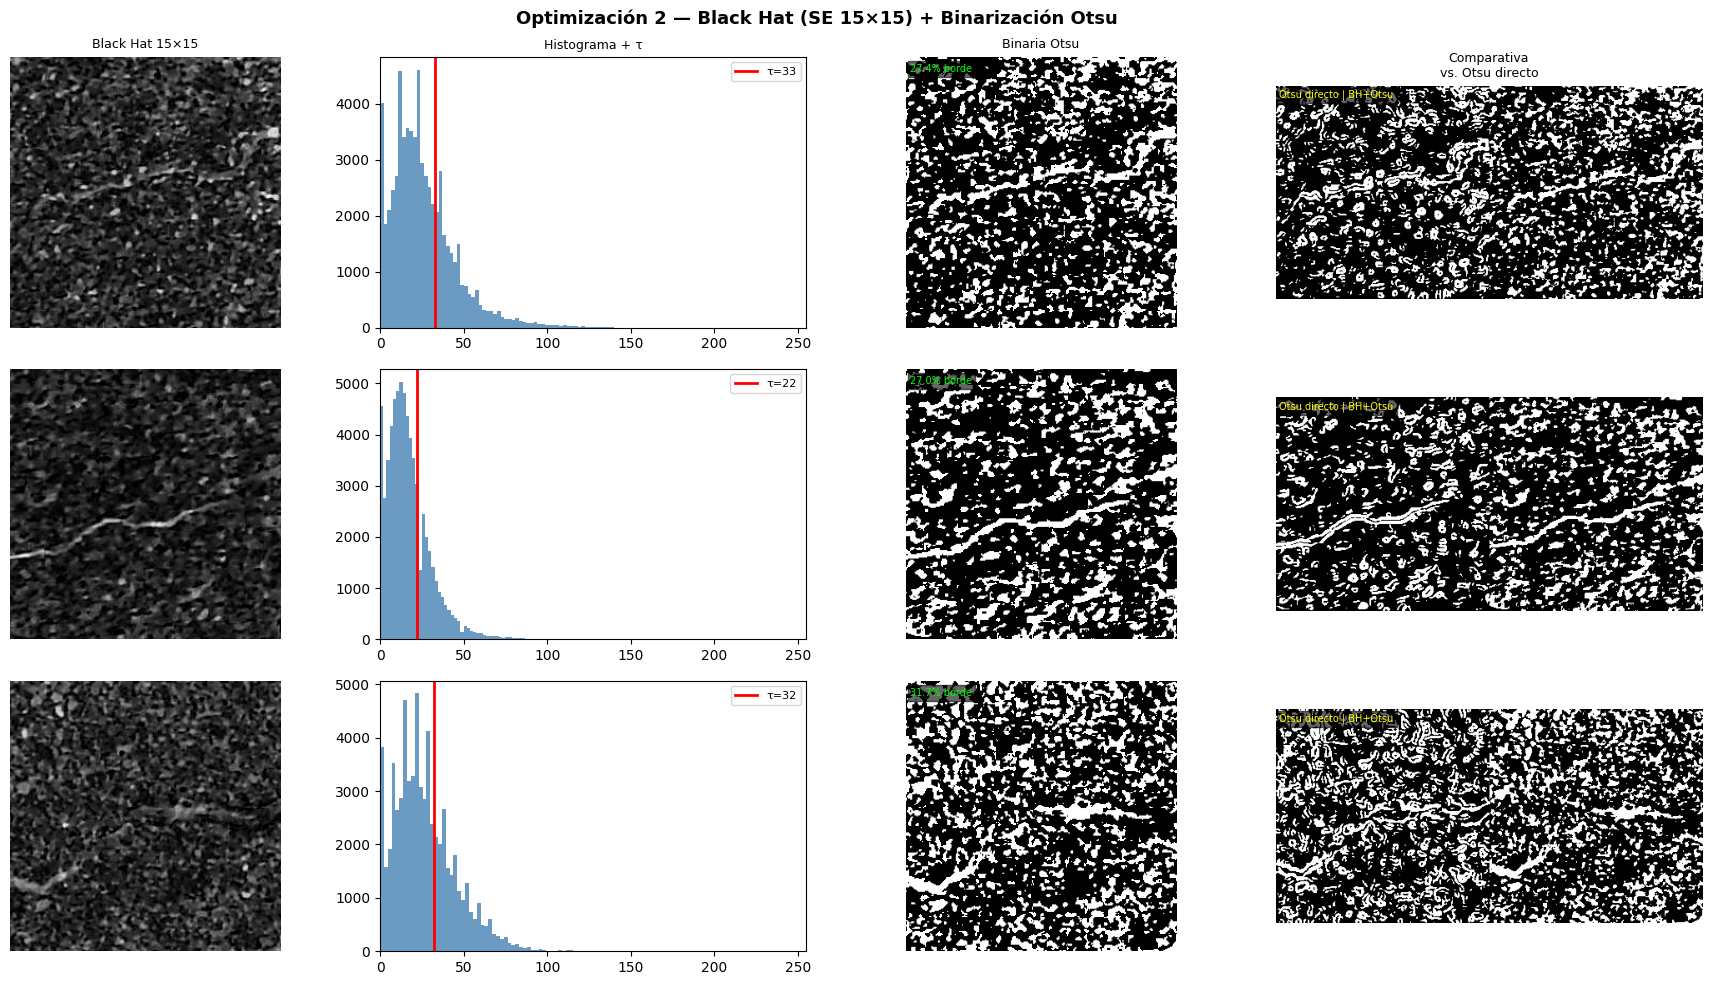

In [23]:
# ── Optimización 2: Black Hat (SE 15x15) + Otsu ───────────────────────────
SE_BH_OPT = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
binarias_bh = {}

fig, axes = plt.subplots(len(imgs_gray), 4, figsize=(18, 10))
fig.suptitle("Optimización 2 — Black Hat (SE 15×15) + Binarización Otsu",
             fontsize=13, fontweight="bold")

titulos = ["Black Hat 15×15", "Histograma + τ", "Binaria Otsu", "Comparativa\nvs. Otsu directo"]

for fila, (nombre, gray) in enumerate(imgs_gray.items()):
    bh  = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, SE_BH_OPT)
    tau = threshold_otsu(bh)
    bin_bh = (bh > tau).astype(np.uint8) * 255
    binarias_bh[nombre] = bin_bh
    pct = bin_bh.mean() / 255 * 100

    # Black Hat
    axes[fila, 0].imshow(bh, cmap="gray")
    if fila == 0: axes[fila, 0].set_title(titulos[0], fontsize=9)
    axes[fila, 0].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8)

    # Histograma
    axes[fila, 1].hist(bh.ravel(), bins=64, color="steelblue", alpha=0.8)
    axes[fila, 1].axvline(tau, color="red", lw=2, label=f"τ={tau:.0f}")
    axes[fila, 1].legend(fontsize=8)
    axes[fila, 1].set_xlim(0, 255)
    if fila == 0: axes[fila, 1].set_title(titulos[1], fontsize=9)

    # Binaria Black Hat + Otsu
    axes[fila, 2].imshow(bin_bh, cmap="gray")
    if fila == 0: axes[fila, 2].set_title(titulos[2], fontsize=9)
    axes[fila, 2].axis("off")
    axes[fila, 2].text(4, 14, f"{pct:.1f}% borde",
        color="lime", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

    # Comparativa: Otsu directo vs Black Hat + Otsu
    comparativa = np.hstack([binarias[nombre], bin_bh])
    axes[fila, 3].imshow(comparativa, cmap="gray")
    if fila == 0: axes[fila, 3].set_title(titulos[3], fontsize=9)
    axes[fila, 3].axis("off")
    axes[fila, 3].text(4, 14, "Otsu directo | BH+Otsu",
        color="yellow", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.savefig("fig_05c_blackhat_otsu.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis — Optimizaciones del Top Hat

**Optimización 1 — tamaño del SE:**

| SE | Observación |
|---|---|
| 15×15 | Fondo más oscuro y uniforme — mayor selectividad |
| 25×25 | Equilibrio — capta grieta pero algo de iluminación |
| 35×35 | Captura variaciones de iluminación del fondo |

Seleccionado: **SE 15×15** por mayor limpieza del fondo.

**Optimización 2 — Black Hat + Otsu:**

| Imagen | Mejora respecto a Otsu directo |
|---|---|
| Grieta sutil | Sin mejora significativa — ruido similar |
| Grieta visible | Grieta más continua y definida ✅ |
| Grieta ramificada | Sin mejora — textura sigue dominando |

**Conclusión:** el Black Hat mejora la separabilidad en imágenes con grieta
de alto contraste, pero no resuelve el problema en imágenes con textura
dominante. El histograma del Black Hat sigue sin ser bimodal, lo que
limita la efectividad de Otsu independientemente de la entrada.

### Análisis del resultado — Top Hat y Black Hat

| Imagen | std original | std White TH | std Black Hat | std Realzada |
|---|---|---|---|---|
| Grieta sutil | 19.8 | 20.6 | 20.6 | 38.0 |
| Grieta visible | 14.6 | 14.1 | 14.4 | 27.1 |
| Grieta ramificada | 20.3 | 18.8 | 19.6 | 37.1 |

**Observaciones:**
- El **Black Hat** resulta más efectivo que el White Top Hat para este
  tipo de imagen — las grietas son estructuras oscuras sobre fondo claro,
  que es exactamente lo que el Black Hat extrae.
- El White Top Hat resalta las variaciones claras de la textura del concreto
  en lugar de la grieta, produciendo un resultado menos útil para el reto.
- La imagen Realzada (original + Top Hat) duplica aproximadamente el std,
  confirmando un aumento significativo del contraste global.
- Limitación: el SE de 25×25 captura también variaciones graduales de
  iluminación del fondo, no solo la grieta.

**Siguiente paso natural:** optimizar el tamaño del SE del Black Hat
para maximizar la selectividad hacia la grieta, y combinar el resultado
con umbralización de Otsu para obtener una máscara binaria más limpia
que la obtenida con el pipeline Sobel → Otsu → Morfología.

---
## proceso — decisiones tomadas

El punto de partida fue un problema concreto: las grietas en superficies de
concreto son estructuras lineales muy delgadas (1–5 px de ancho) sobre un
fondo con textura rugosa, donde las variaciones de intensidad del concreto
compiten visualmente con la señal de la grieta. El objetivo era hacer visible
lo que el ojo apenas distingue y aislar esa estructura de forma verificable.

**Primera decisión — trabajar en escala de grises.**
Las grietas se distinguen del concreto por diferencia de intensidad, no de
color. Convertir a gris elimina dos canales innecesarios sin perder información
relevante para el problema.

**Segunda decisión — preprocesado con filtro bilateral.**
Inicialmente se evaluó el filtro Gaussiano, que reduce el ruido pero suaviza
también los bordes de la grieta. Al compararlo con el filtro de mediana y el
bilateral, se evidenció que el bilateral preserva mejor los bordes abruptos
de la grieta mientras suaviza el fondo uniforme del concreto — porque pondera
cada píxel vecino no solo por distancia sino también por similitud de
intensidad. Se seleccionó d=9 como equilibrio entre suavizado y costo
computacional.

**Tercera decisión — detección de bordes con Sobel.**
Se compararon Sobel y Laplaciano sobre la imagen preprocesada. El Laplaciano
produce bordes más finos pero es más sensible al ruido residual y resultó
menos efectivo en la grieta ramificada, donde el contraste con el fondo es
bajo. Sobel demostró mayor robustez en las tres imágenes, aunque resalta
también imperfecciones de la textura del concreto — limitación esperada que
se traslada a las etapas siguientes.

**Cuarta decisión — binarización con umbral de Otsu.**
Para pasar de una imagen en escala de grises a una máscara binaria que
permitiera aplicar morfología, se eligió Otsu por su capacidad de calcular
el umbral óptimo automáticamente desde el histograma, sin intervención manual.
Se identificó una limitación importante: el histograma de Sobel no es bimodal
en este tipo de imagen, lo que lleva a Otsu a clasificar demasiada textura
como borde. La binaria resultante contiene la grieta pero con alto ruido
puntual.

**Quinta decisión — morfología con Disco 3×3.**
Se evaluaron cuatro elementos estructurantes (Disco 3×3, Disco 7×7, Rect H
9×3, Rect V 3×9) para limpiar el ruido puntual mediante apertura y rellenar
huecos mediante cierre. Los SEs mayores demostraron ser incompatibles con el
ancho real de la grieta — la erosión previa a la apertura la destruye antes
de poder recuperarla. El Disco 3×3 es el mínimo viable: reduce el ruido
parcialmente sin sacrificar la grieta, aunque el resultado sigue teniendo
ruido residual por la limitación de Otsu en la etapa anterior.

**Sexta decisión — Black Hat como operación avanzada.**
Se evaluaron White Top Hat y Black Hat sobre la imagen bilateral en gris.
El White Top Hat extrae estructuras claras sobre fondo oscuro — lo opuesto
a lo que necesitamos, ya que la grieta es oscura sobre concreto claro. El
Black Hat resultó más efectivo porque extrae exactamente estructuras oscuras
sobre fondo claro, operando directamente sobre la imagen en gris sin depender
de la binarización ruidosa de Otsu. Se optimizó el SE del Black Hat comparando
15×15, 25×25 y 35×35, seleccionando 15×15 por producir el fondo más uniforme
sin perder definición en la grieta. El resultado del Black Hat binarizado con
Otsu es el más limpio del pipeline — con la grieta visible claramente aislada
en la imagen de mayor contraste.

**Conclusión del proceso.**
A lo largo de este trabajo demostré que la detección de grietas en concreto
mediante métodos clásicos de visión artificial es viable pero exige decisiones
bien justificadas en cada etapa. No encontré un filtro universal — cada
decisión que tomé respondió a una limitación concreta identificada en el paso
anterior: el Gaussiano suavizaba demasiado los bordes, entonces opté por el
bilateral; Otsu generaba demasiado ruido en la binaria, entonces usé la
morfología para compensarlo; la morfología tenía margen limitado por el ancho
real de la grieta, entonces recurrí al Black Hat como vía alternativa más
directa sobre la imagen en gris. El resultado final no es perfecto — la grieta
sutil sigue siendo difícil de aislar completamente — pero el proceso iterativo
de evaluar, comparar y ajustar cada parámetro es exactamente el enfoque
correcto para este tipo de problema. Las limitaciones que identifiqué no son
fracasos del pipeline sino insumos valiosos para orientar mejoras futuras,
como el uso de umbrales adaptativos locales, el detector de Canny, o métodos
de aprendizaje profundo entrenados específicamente sobre imágenes de
infraestructura en concreto.

---
## Conclusiones Generales

### Eficacia del pipeline por etapa

| Etapa | Técnica seleccionada | Efectividad | Limitación identificada |
|---|---|---|---|
| Preprocesado | Filtro Bilateral d=9 | Alta — preserva bordes mejor que Gaussiano | Más lento computacionalmente |
| Detección de bordes | Sobel | Media-alta — robusto ante bajo contraste | Resalta también textura del concreto |
| Binarización | Otsu | Media — funciona sin intervención manual | Histograma no bimodal → umbral subóptimo |
| Morfología | Apertura+Cierre Disco 3×3 | Media — reduce ruido puntual | SE mínimo viable — ruido residual persiste |
| Extracción avanzada | Black Hat 15×15 + Otsu | Alta — mejor resultado visual del pipeline | Captura variaciones de iluminación del fondo |

### Hallazgos principales

1. **El Black Hat sobre imagen bilateral es la combinación más efectiva** 
   para detectar grietas en concreto — opera directamente en escala de grises
   sin depender de una binarización previa ruidosa.

2. **El preprocesado bilateral marca una diferencia real** respecto al
   Gaussiano — al preservar los bordes de la grieta mientras suaviza el fondo,
   mejora todas las etapas posteriores del pipeline.

3. **La umbralización de Otsu es subóptima para este tipo de imagen** — el
   histograma de Sobel no es bimodal, lo que resulta en clasificación excesiva
   de textura como borde. Es funcional pero genera ruido que la morfología
   no logra eliminar completamente.

4. **El tamaño del elemento estructurante es crítico** — con grietas de 1–5 px
   de ancho, cualquier SE mayor que 3×3 destruye la estructura durante la
   erosión. Esto limita la capacidad de limpieza morfológica.

### Limitaciones y líneas futuras

- **Filtrado adaptativo:** un umbral local (Niblack, Sauvola) en lugar de
  Otsu global podría separar mejor grieta y textura en imágenes con
  iluminación no uniforme.
- **Detector de Canny:** combina suavizado, Sobel, supresión de no-máximos
  e histéresis — podría producir bordes más limpios que Sobel+Otsu.
- **Morfología direccional:** un SE lineal orientado según la dirección
  predominante de cada grieta podría mejorar la extracción preservando
  la estructura sin destruirla.
- **Aprendizaje profundo:** redes como U-Net entrenadas sobre SDNET2018
  superan los métodos clásicos en precisión de segmentación, aunque
  requieren datos etiquetados y mayor costo computacional.